<center><h1>INF-552 Lab 0</h1></center>
<br>
<center><font size="4">Introduction to Basic Development Tools</font></center>

### Rules

1. Please read the instructions and problem prompts **carefully**.
2. This lab is to give you some basic APIs of numpy, pandas and scikit-learn. Besides, some topics such as how to make your jupyter notebook be a more efficient developing tools, how to use git and GitHub will also be covered. The lab is to be done individually. You may talk to your fellow classmates about general issues ("Remind me again: Which API should I used for doing group by operation to a data set") but about the specifies of how to do these exercises.
3. Along with a similar vein, you can ask the TA for help, but ask questions about **concepts** but not ask the TA to help you debug your code. The TA is here to help, but not to do the work for you.
4. You are welcome to use the class resources and the Internet.
5. Playing with variations. Solve one problems, and then copy the code to a new cell and play around with it. Doing this is the single most important thing when learning programming.
6. This lab will not be graded but the content is highly related to your future programming assignments. So, treat it wisely.
7. All the content having been gone though in the week 1 discussion is just a snapshot of the most basic concepts. **You need to keep study more about Git, GitHub, Pandas, Numpy and Scikit-Learn in order to finish your programming assignments successfully.**
8. Have fun!

### Setup Development Environment

There are many ways to setup the environment. But, I do recommend a simple idea that is using the Anaconda, which is a pre-build python environment with bundles of useful packages.

**To download the Anaconda, go to the following website:
https://www.anaconda.com/distribution/**. Download the correct version based on your operating system and install it step by step.

Then, **configure your PATH environment variable** to make the conda command work. The following command is an easy way to test whether your configuration is correct. If it is, you will see something as like as the sample output.

> **command:**
>
> conda --version
>
> **sample output:**
>
> conda 4.6.12

**Finally, download this jupyter notebook file,** then change the working directory to where its location in terminal, and type the following command to open the jupter notebook and finish the lab.

> **command:** 
> jupyter notebook

In [1]:
import pandas as pd
import numpy as np

### Pandas

#### The read_csv() Method

First, read the documentation about the *read_csv()* method in Pandas (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html). Then, try to read data from file Salaries.csv to a dataframe, make the column playerID in the csv file as the index column and the first row as the header. Also, skip the second row when reading the file.

In [2]:
# 读取数据，清洗表头和索引
df = pd.read_csv('Salaries.csv', header=0, skiprows=[1], index_col='playerID')

# 打印前 5 行核对数据格式
df.head()

,yearID,teamID,lgID,salary
playerID,,,,
bedrost01,1985,ATL,NL,550000
benedbr01,1985,ATL,NL,545000
campri01,1985,ATL,NL,633333
ceronri01,1985,ATL,NL,625000
chambch01,1985,ATL,NL,800000


#### Indexing and Selecting Data

Select the id of the players who are registered in ATL and HOU and whose salary is higher than one million.

In [3]:
# 假设球队列名为 'teamID'，薪水列名为 'salary' (具体以你的 Salaries.csv 实际表头为准)
# 使用 () 将每个条件括起来，| 代表 "或" (OR)，& 代表 "且" (AND)
condition = ((df['teamID'] == 'ATL') | (df['teamID'] == 'HOU')) & (df['salary'] > 1000000)

# 应用条件筛选出符合要求的数据行
filtered_df = df[condition]

# 题目要求获取球员的 ID，因为我们在第一步已经把 playerID 设为了索引 (Index)
# 所以直接提取 index 并转换为列表输出
high_paid_players_id = filtered_df.index.tolist()

print(f"符合条件的球员数量: {len(high_paid_players_id)}")
print("球员 ID 列表:", high_paid_players_id[:10], "...") # 打印前 10 个检查一下

符合条件的球员数量: 595
球员 ID 列表: ['hornebo01', 'murphda05', 'suttebr01', 'ryanno01', 'hornebo01', 'murphda05', 'suttebr01', 'ryanno01', 'griffke01', 'murphda05'] ...


#### The describe() Method

Calculate the standard Deviation, first quartile, medium, third quartile, mean, maximum, minimum of the salary in team ATL.

In [4]:
# 筛选出 ATL 队的数据，然后提取 'salary' 列，最后调用 describe()
atl_salary_stats = df[df['teamID'] == 'ATL']['salary'].describe()

# 打印结果
print("ATL 队薪水统计信息：")
print(atl_salary_stats)

ATL 队薪水统计信息：
count    8.850000e+02
mean     2.207749e+06
std      3.434320e+06
min      6.000000e+04
25%      3.000000e+05
50%      6.000000e+05
75%      2.400000e+06
max      1.606180e+07
Name: salary, dtype: float64


#### The iterrows() Method

Create a Python dictionary object whose keys are the headers of the dataframe created in the read_csv() exercise and values are Python list objects that contain data corresponding to the headers. (Here, use the iterrows method to iterate each row of the dataframe and copy it to a dictionary. However, there is a easier way. Learn how the to_dict() method works by yourself later)

In [5]:
# 初始化字典，键为表头，值为空列表
dict_from_df = {header: [] for header in df.columns}

# 逐行遍历并填入字典
for index, row in df.iterrows():
    for header in df.columns:
        dict_from_df[header].append(row[header])

print("字典创建成功！包含的键有:", list(dict_from_df.keys()))

字典创建成功！包含的键有: ['yearID', 'teamID', 'lgID', 'salary']


#### Create Dataframe Using the Constructor

Read the documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html#pandas.DataFrame and create a dataframe using pd.DataFrame from the dictionary created in the iterrows() exercise. Change the header to "a", "b", "c", ... at creation time.

In [6]:
# 使用刚才建立的字典创建 DataFrame
new_df = pd.DataFrame(dict_from_df)

# 根据题目要求，更改表头名字为 a, b, c, d
new_df.columns = ['a', 'b', 'c', 'd']

# 打印前 5 行检查结果
print("重命名表头后的新 DataFrame:")
print(new_df.head())

重命名表头后的新 DataFrame:
      a    b   c       d
0  1985  ATL  NL  550000
1  1985  ATL  NL  545000
2  1985  ATL  NL  633333
3  1985  ATL  NL  625000
4  1985  ATL  NL  800000


### Numpy

Quick start: https://www.numpy.org/devdocs/user/quickstart.html

Numpy axes explaination: https://www.sharpsightlabs.com/blog/numpy-axes-explained/

#### The np.array Method

Example 1:

```python
ls = [1, 2, 3]
arr = np.array(ls)
```

Example 2:
```python
>>> np.array([[1, 2], [3, 4]])
array([[1, 2],
       [3, 4]])
```

Now, create a 2-dimensional Python list object, then convert it to a Numpy array object.

In [7]:
# 创建一个 2 维的 Python 列表 (比如 2行3列)
my_2d_list = [[10, 20, 30], [40, 50, 60]]

# 转换为 Numpy 数组
my_arr = np.array(my_2d_list)

print("转换成功的 Numpy Array:\n", my_arr)

转换成功的 Numpy Array:
 [[10 20 30]
 [40 50 60]]


#### ndarray Objects' Attributes

Play with the **ndim, shape, size, dtype, itemsize and data** attribute.

Example:

```python
>>> arr = np.array([[1, 2], [3, 4]])
>>> arr.ndim
2
```

In [8]:
# 直接复用上面跑出来的 my_arr 打印属性
print("1. ndim (维度数):", my_arr.ndim)
print("2. shape (矩阵形状/行列):", my_arr.shape)
print("3. size (总元素个数):", my_arr.size)
print("4. dtype (数据类型):", my_arr.dtype)
print("5. itemsize (单个元素占用字节):", my_arr.itemsize)
print("6. data (内存缓冲区指针):", my_arr.data)

1. ndim (维度数): 2
2. shape (矩阵形状/行列): (2, 3)
3. size (总元素个数): 6
4. dtype (数据类型): int64
5. itemsize (单个元素占用字节): 8
6. data (内存缓冲区指针): <memory at 0x13feadbe0>


#### Dimension of ndarray Ojects

Play with the reshape() and flatten() method.

Example:
```python
>>> arr = np.array([[1, 2], [3, 4]])
>>> arr.flatten()
array([1, 2, 3, 4])
```

In [9]:
# 原本的 my_arr 是 2行3列
print("原始矩阵 (2x3):\n", my_arr)

# flatten(): 把矩阵压扁成一维数组
print("\nFlatten (展平为1维):", my_arr.flatten())

# reshape(): 在总元素数量不变的前提下，重新捏造形状 (比如变成 3行2列)
print("\nReshape (重塑为 3x2):\n", my_arr.reshape(3, 2))

原始矩阵 (2x3):
 [[10 20 30]
 [40 50 60]]

Flatten (展平为1维): [10 20 30 40 50 60]

Reshape (重塑为 3x2):
 [[10 20]
 [30 40]
 [50 60]]


#### The Slice Operation of ndarray Objects

Understand how the slice operation works for 1-D array and 2-D array.

Example:

```python
>>> arr = np.array([[1, 2, 3], [3, 4, 6], [7, 8, 9]])
>>> arr[1:]
array([[3, 4, 6],
       [7, 8, 9]])
>>> arr[1:, 0:2]
array([[3, 4],
       [7, 8]])
```

In [10]:
# 我们新建一个 3x3 的矩阵来演示切片
arr_slice = np.array([[1, 2, 3], 
                      [4, 5, 6], 
                      [7, 8, 9]])
print("原 3x3 矩阵:\n", arr_slice)

# 1-D 切片：只提取第一行 (索引从0开始)
print("\n提取第一行:", arr_slice[0])

# 2-D 切片：提取所有行 (用 : 表示)，并且只取前两列 (用 0:2 表示)
print("\n提取所有行的前两列:\n", arr_slice[:, 0:2])

# 2-D 切片：提取第二行及之后的所有行，第二列及之后的所有列
print("\n提取右下角 2x2 矩阵:\n", arr_slice[1:, 1:])

原 3x3 矩阵:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

提取第一行: [1 2 3]

提取所有行的前两列:
 [[1 2]
 [4 5]
 [7 8]]

提取右下角 2x2 矩阵:
 [[5 6]
 [8 9]]


#### The Calculation of ndarray Objects

Play with the **argmin(), argmax(), min(), max(), mean(), sum(), std(), dot(), square(), sqrt(), abs(). exp(), sign(), mod()** method.

Example:

```python
>>> np.square(array)
array([[ 1,  4,  9],
       [ 9, 16, 36],
       [49, 64, 81]])

```

In [11]:
import numpy as np

# 新建一个包含正负数的 2x3 测试矩阵
arr_calc = np.array([[-1, 2, 3], [4, -5, 6]])
print("原始测试矩阵:\n", arr_calc)

print("\n--- 基础统计 ---")
print("min:", arr_calc.min(), " | max:", arr_calc.max())
print("argmin (最小值的全局索引):", arr_calc.argmin())
print("argmax (最大值的全局索引):", arr_calc.argmax())
print("mean (均值):", arr_calc.mean(), " | sum (总和):", arr_calc.sum(), " | std (标准差):", arr_calc.std())

print("\n--- 数学运算 ---")
print("square (平方):\n", np.square(arr_calc))
print("abs (绝对值):\n", np.abs(arr_calc))
print("sign (符号提取, 正为1负为-1):\n", np.sign(arr_calc))
print("exp (指数 e^x):\n", np.exp(arr_calc))
print("mod (对3取模):\n", np.mod(arr_calc, 3))

# sqrt 要求非负数，我们对它的绝对值矩阵求平方根
print("\nsqrt (对绝对值矩阵开方):\n", np.sqrt(np.abs(arr_calc)))

print("\n--- 矩阵点乘 (Dot Product) ---")
# dot 点乘要求维度匹配 (比如 2x3 矩阵 乘以 3x2 矩阵)
arr_dot = np.array([[1, 2], [3, 4], [5, 6]])
print("dot (2x3 点乘 3x2):\n", arr_calc.dot(arr_dot))

原始测试矩阵:
 [[-1  2  3]
 [ 4 -5  6]]

--- 基础统计 ---
min: -5  | max: 6
argmin (最小值的全局索引): 4
argmax (最大值的全局索引): 5
mean (均值): 1.5  | sum (总和): 9  | std (标准差): 3.593976442141304

--- 数学运算 ---
square (平方):
 [[ 1  4  9]
 [16 25 36]]
abs (绝对值):
 [[1 2 3]
 [4 5 6]]
sign (符号提取, 正为1负为-1):
 [[-1  1  1]
 [ 1 -1  1]]
exp (指数 e^x):
 [[3.67879441e-01 7.38905610e+00 2.00855369e+01]
 [5.45981500e+01 6.73794700e-03 4.03428793e+02]]
mod (对3取模):
 [[2 2 0]
 [1 1 0]]

sqrt (对绝对值矩阵开方):
 [[1.         1.41421356 1.73205081]
 [2.         2.23606798 2.44948974]]

--- 矩阵点乘 (Dot Product) ---
dot (2x3 点乘 3x2):
 [[20 24]
 [19 24]]


#### Other Important Methods Inside Module Numpy

Play with the arange(), ones(), zeros(), eye(), linspace(), concatenate() method.

Example:

```python
>>> np.eye(3)
array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])
```

In [12]:
print("1. arange (生成0到9，步长为2的序列):", np.arange(0, 10, 2))
print("\n2. ones (生成 2x2 全 1 矩阵):\n", np.ones((2, 2)))
print("\n3. zeros (生成 2x3 全 0 矩阵):\n", np.zeros((2, 3)))
print("\n4. eye (生成 3x3 单位对角矩阵):\n", np.eye(3))
print("\n5. linspace (0到1之间等距取5个数):", np.linspace(0, 1, 5))

# 6. concatenate (矩阵拼接)
arr_a = np.array([[1, 2], [3, 4]])
arr_b = np.array([[5, 6]])
print("\n6. concatenate (按行拼接):\n", np.concatenate((arr_a, arr_b), axis=0))

1. arange (生成0到9，步长为2的序列): [0 2 4 6 8]

2. ones (生成 2x2 全 1 矩阵):
 [[1. 1.]
 [1. 1.]]

3. zeros (生成 2x3 全 0 矩阵):
 [[0. 0. 0.]
 [0. 0. 0.]]

4. eye (生成 3x3 单位对角矩阵):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

5. linspace (0到1之间等距取5个数): [0.   0.25 0.5  0.75 1.  ]

6. concatenate (按行拼接):
 [[1 2]
 [3 4]
 [5 6]]


### Scikit-Learn

The followings are packages (or methods) in Python (Scikit-Learn and Scipy) that will be frequently used in your programming assignment. So, please read carefully.

- Data Preprocessing (https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing)
    - Standardization: StandardScaler
    - Normalization: MinMaxScaler
    - Quantifing Categorical Features: LabelEncoder. OneHotEncoder
    - Construct Train and Test Set: model_selection.train_test_split
- KNN: KNeighborsClassifier
- Linear Regression: LinearRegression
- Logistic Regression: LogisticRegression, LogisticRegressionCV
- Feature Selection / Model Selection
    - L1 Penalized Regression (Lasso Regression) with Cross-Validation: LassoCV
    - L2 Penalized Regression (Ridge Regression) with Cross-Validation: RidgeCV
    - Cross-Validation: StratifiedKFold, RepeatedKFold, LeaveOneOut, KFold, model_selection.cross_validate, model_selection.cross_val_predict, model_selection.cross_val_score
    - Model Metrics (https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics): accuracy_score, auc, f1_score, hamming_loss, precision_score, recall_score, roc_auc_score
- Decision Tree: DecisionTreeClassifier, DecisionTreeRegressor
- Bootstrap, Ensemble Methods
    - Bootstrap: bootstrapped (https://pypi.org/project/bootstrapped/)
    - Bagging: RandomForestClassifier, RandomForestRegressor
    - Boosting: AdaBoostClassifier, AdaBoostRegressor
- Support Vector Machines (https://scikit-learn.org/stable/modules/svm.html#svm): LinearSVC, LinearSVR
- Multiclass and Multilabel Classification (https://scikit-learn.org/stable/modules/classes.html#module-sklearn.multiclass)
    - One-vs-one Multiclass Strategy: OneVsOneClassifier
    - One-vs-the-rest (OvR) multiclass/multilabel strategy / OneVsRestClassifier
- Unsupervised Learning
    - K-means Clustering: KMeans
    - Hierarchical Clustering: scipy.cluster.hierarchy (not scikit-learn)
- Semisupervised Learning (https://scikit-learn.org/stable/modules/label_propagation.html)

### Matplotlib

**Quick start:** https://matplotlib.org/3.1.1/tutorials/introductory/pyplot.html

**Exercises:**

(a) Create two one dimensional arrays x and y and plot y vs x, add title, xlabel, ylabel, grid.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])
```

copy the code above to the following cell and add code for plotting the parabola.

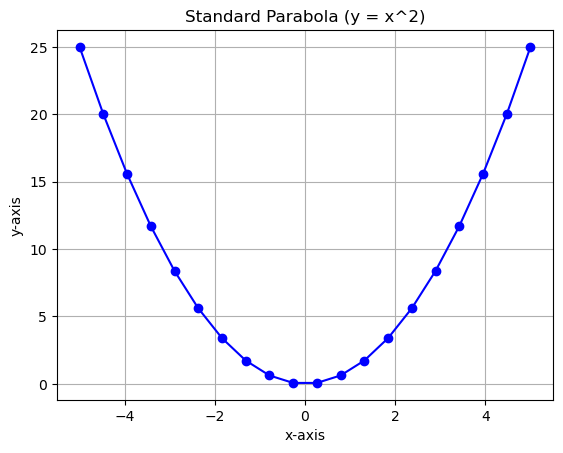

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 题目给定的原始数据
x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])

# 绘制图表 (加入 marker='o' 可以清晰看到具体的点)
plt.plot(x, y, marker='o', linestyle='-', color='b')

# 添加题目要求的各元素
plt.title('Standard Parabola (y = x^2)')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.grid(True)

# 展示图表
plt.show()

What happens if the independent variable is not sorted before plotting? Try plotting directly using the following defined array.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
np.random.shuffle(x)
y = np.array([j ** 2 for j in x])
```

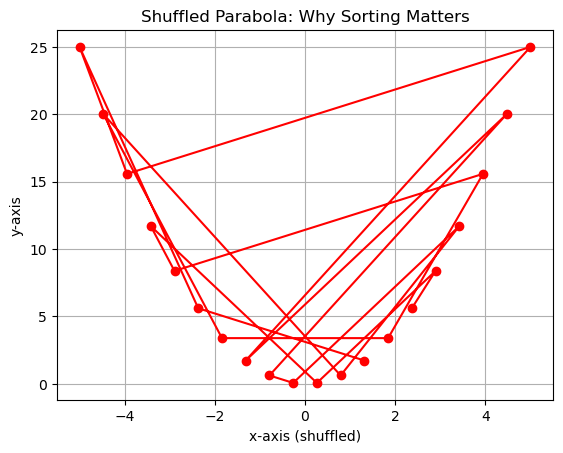

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 题目给定的打乱顺序的数据
x = np.linspace(-5, 5, num=20)
np.random.shuffle(x)
y = np.array([j ** 2 for j in x])

# 绘制图表
plt.plot(x, y, marker='o', linestyle='-', color='r')

# 添加元素
plt.title('Shuffled Parabola: Why Sorting Matters')
plt.xlabel('x-axis (shuffled)')
plt.ylabel('y-axis')
plt.grid(True)

# 展示图表
plt.show()

(b) Create multiple arrays and plot them with different styles, add legends, add text/mathematical equations on the plot.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])
```

copy the code above to the following cell and add code for plotting curve $\left(x, y1\right)$, $\left(x, y2\right)$ and $\left(x, y3\right)$.

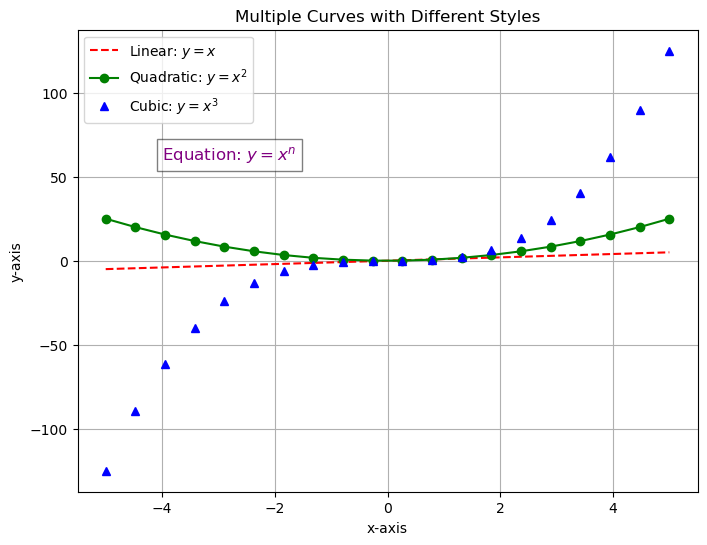

In [15]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])

plt.figure(figsize=(8, 6))

# 绘制三条曲线，使用不同的样式(不同颜色、线型、标记)和标签
plt.plot(x, y1, 'r--', label='Linear: $y=x$')      # 红色虚线
plt.plot(x, y2, 'g-o', label='Quadratic: $y=x^2$') # 绿色实线带圆点
plt.plot(x, y3, 'b^', label='Cubic: $y=x^3$')      # 蓝色三角形

# 添加图例，并设置位置在左上角
plt.legend(loc='upper left')
plt.title('Multiple Curves with Different Styles')
plt.xlabel('x-axis')
plt.ylabel('y-axis')

# 在图表特定坐标(x=-4, y=60)处添加数学公式文本，支持 LaTeX 格式
plt.text(-4, 60, r'Equation: $y = x^n$', fontsize=12, color='purple', 
         bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True)
plt.show()

(c) Create multiple arrays and plot them into one figure **(No multiple figure and no subplot is allowed in this question)**.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])
```

copy the code above to the following cell and add code for plotting curve $\left(x, y1\right)$, $\left(x, y2\right)$ and $\left(x, y3\right)$.

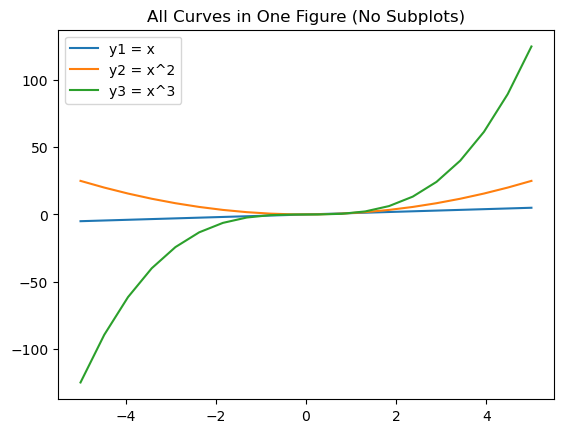

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])

# 直接在一张图 (同一个坐标系) 里绘制所有的线
plt.plot(x, y1, label='y1 = x')
plt.plot(x, y2, label='y2 = x^2')
plt.plot(x, y3, label='y3 = x^3')

plt.title('All Curves in One Figure (No Subplots)')
plt.legend()
plt.show()

(d) Create multiple subplots, play around with the figure size, figure title, and its font style and font size **(One curve is plotted in one subplot in this question)**.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])
```

copy the code above to the following cell and add code for plotting curve $\left(x, y1\right)$, $\left(x, y2\right)$ and $\left(x, y3\right)$.

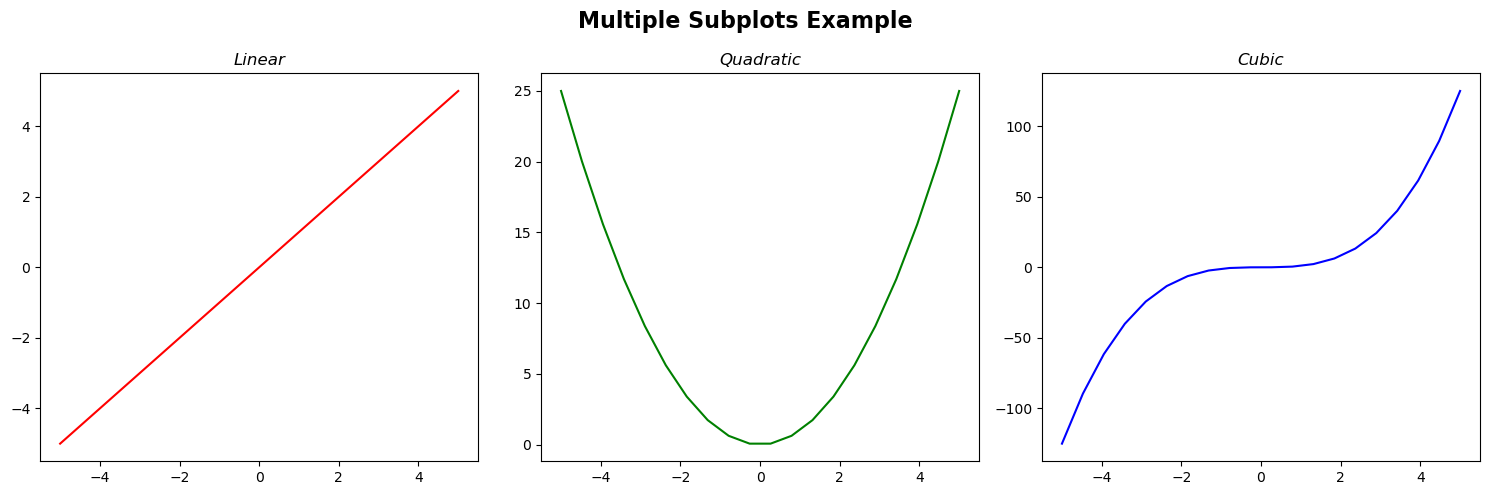

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y1 = np.array([j for j in x])
y2 = np.array([j ** 2 for j in x])
y3 = np.array([j ** 3 for j in x])

# 创建 1 行 3 列的子图，设置画板长宽比为 15:5
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# 设置总标题，指定字体大小、加粗和字体系列
fig.suptitle('Multiple Subplots Example', fontsize=16, fontweight='bold', fontfamily='sans-serif')

# 第一个子图
axs[0].plot(x, y1, 'r')
axs[0].set_title('Linear', fontsize=12, fontstyle='italic')

# 第二个子图
axs[1].plot(x, y2, 'g')
axs[1].set_title('Quadratic', fontsize=12, fontstyle='italic')

# 第三个子图
axs[2].plot(x, y3, 'b')
axs[2].set_title('Cubic', fontsize=12, fontstyle='italic')

# 自动调整子图间距，防止文字重叠
plt.tight_layout()
plt.show()

(e) Change the limits on x and y axes, **use logarithmic axes to plot**.

```python
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])
```

copy the code above to the following cell and add code for plotting the parabola.

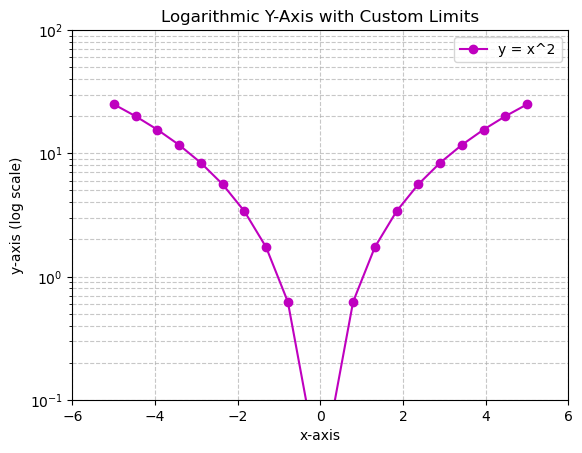

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])

# 绘制基础图表
plt.plot(x, y, 'm-o', label='y = x^2')

# 1. 改变 X 和 Y 轴的范围 (Limits)
# 把 X 轴限制在 -6 到 6，Y 轴限制在 0.1 到 100 (为了避免 log(0) 的警告，y下限稍微大于0)
plt.xlim(-6, 6)
plt.ylim(0.1, 100)

# 2. 使用对数坐标系 (Logarithmic axes)
plt.yscale('log')

# 添加说明元素
plt.title('Logarithmic Y-Axis with Custom Limits')
plt.xlabel('x-axis')
plt.ylabel('y-axis (log scale)')
plt.legend()

# 开启网格线，which="both" 可以让对数坐标的细分网格也显示出来
plt.grid(True, which="both", linestyle='--', alpha=0.7)

plt.show()

### Pandas's DataFrame.plot and Seaborn

#### Pandas's DataFrame.plot

Use the Salaries.csv again (You can use the dataframe object loaded from section 3.1).

(a) For team 'ATL', plot a scatter plot between feature yearID and salary.

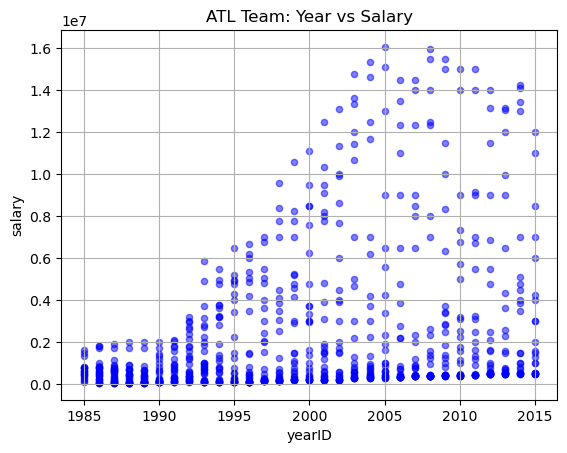

In [20]:
import matplotlib.pyplot as plt

# 筛选 ATL 队，直接调用 DataFrame 的 plot.scatter 方法
df_atl = df[df['teamID'] == 'ATL']
df_atl.plot.scatter(x='yearID', y='salary', title='ATL Team: Year vs Salary', color='blue', alpha=0.5)

plt.grid(True)
plt.show()

(b) For year 1985, plot a bar chart to show the average salary for each team.

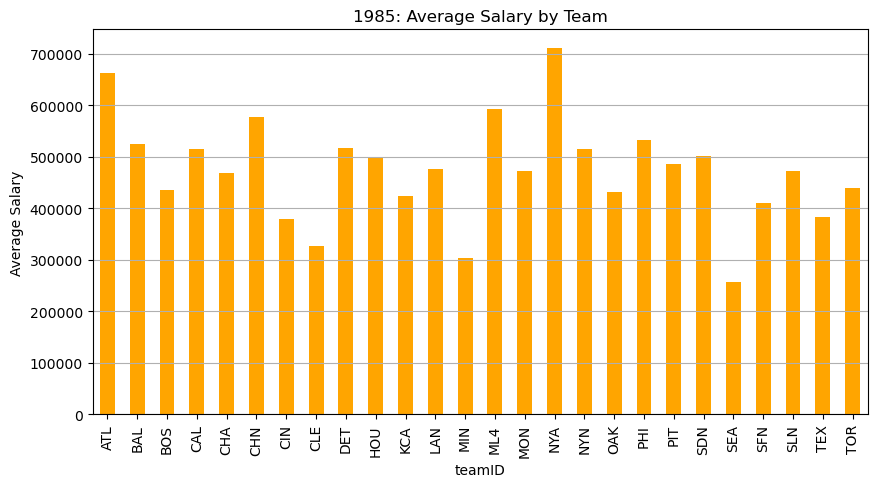

In [21]:
# 筛选 1985 年的数据，按球队分组计算平均薪水
df_1985_mean = df[df['yearID'] == 1985].groupby('teamID')['salary'].mean()

# 绘制柱状图
df_1985_mean.plot.bar(title='1985: Average Salary by Team', color='orange', figsize=(10, 5))

plt.ylabel('Average Salary')
plt.grid(axis='y')
plt.show()

(c) For team 'ATL', plot a line chart to show how the annual average salary change by years.

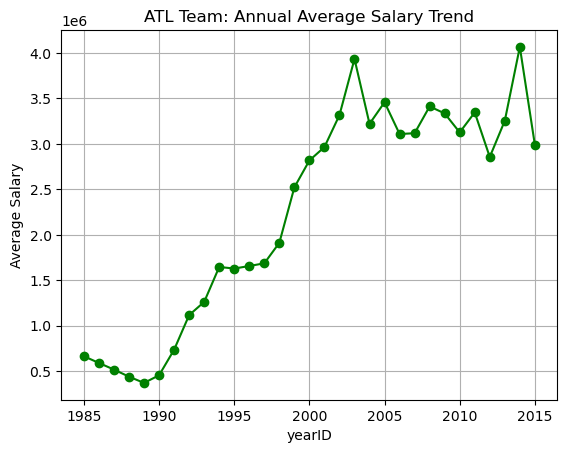

In [22]:
# 筛选 ATL 队，按年份分组计算平均薪水
df_atl_mean_by_year = df[df['teamID'] == 'ATL'].groupby('yearID')['salary'].mean()

# 绘制折线图
df_atl_mean_by_year.plot.line(title='ATL Team: Annual Average Salary Trend', marker='o', color='green')

plt.ylabel('Average Salary')
plt.grid(True)
plt.show()

#### Seaborn

(a) Append one more numeric feature to the data frame (can be generated randomly), then for team 'ATL', use the seaborn.pairplot to plot scatter plots among all numeric features in the data frame for team. 

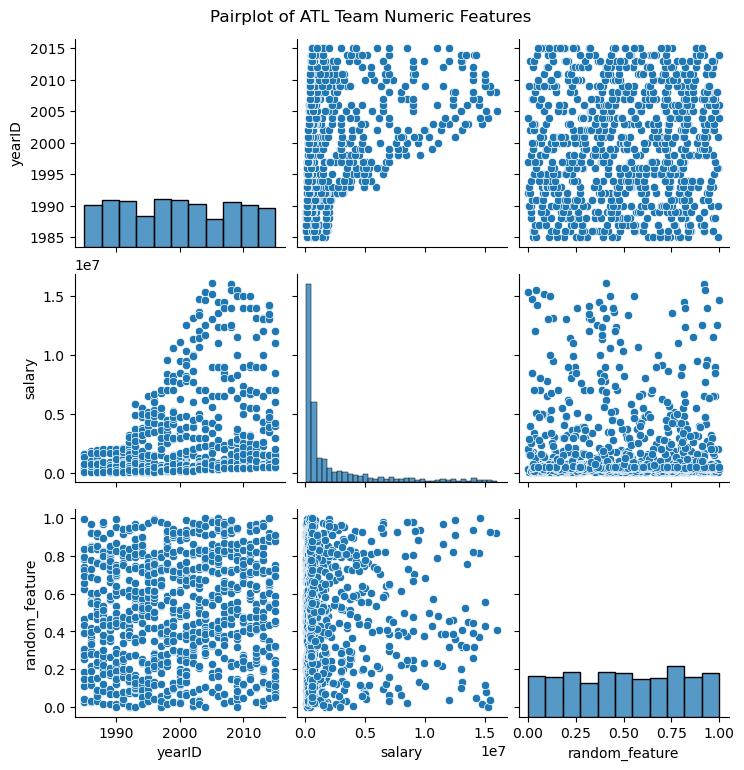

In [23]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. 给原 dataframe 增加一列随机生成的数值特征
df['random_feature'] = np.random.rand(len(df))

# 2. 筛选 ATL 队的数据，并只保留需要做散点图对比的数值列
# 注意：你的实际 df 里可能还有其他数值列，这里为了清晰，我们显式指定这三列
df_atl_subset = df[df['teamID'] == 'ATL'][['yearID', 'salary', 'random_feature']]

# 3. 使用 seaborn 画 pairplot
sns.pairplot(df_atl_subset)
plt.suptitle("Pairplot of ATL Team Numeric Features", y=1.02)
plt.show()

(b) For year 1985 and for each team, plot a boxplot to show how the salary distribute within a team.

/var/folders/lb/nks6wl5j62x6pcq6llh610tr0000gn/T/ipykernel_30198/3950333446.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='teamID', y='salary', data=df_1985, palette='Set3')


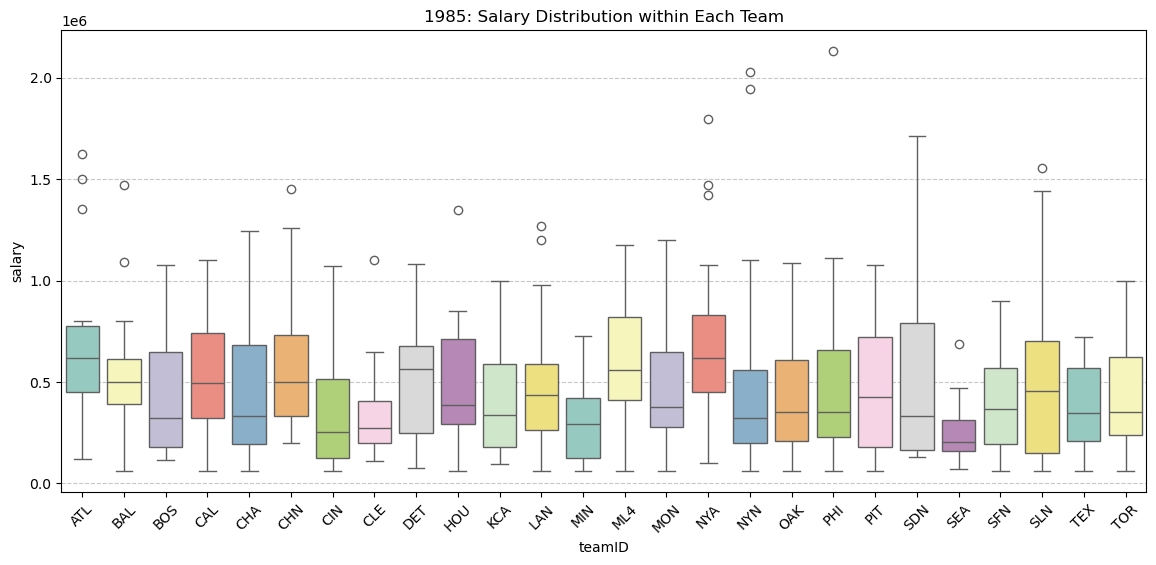

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 筛选 1985 年的数据
df_1985 = df[df['yearID'] == 1985]

# 设置画板大小，因为球队比较多，横向拉长一点避免横坐标文字重叠
plt.figure(figsize=(14, 6))

# 使用 seaborn 绘制箱线图
sns.boxplot(x='teamID', y='salary', data=df_1985, palette='Set3')

plt.title('1985: Salary Distribution within Each Team')
plt.xticks(rotation=45) # 把 X 轴的球队名字倾斜 45 度，防止挤在一起
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

(c) Read the offical documentation (https://seaborn.pydata.org/) to understand how lmplot, catplot, relplot, and jointplot works.

### Jupyter Notebook

#### Jupyter Notebook Extensions

Extensions such as the code formatter, table of content is to make your development more efficient. To explore it, please refer to https://github.com/ipython-contrib/jupyter_contrib_nbextensions.

#### Jupyter Visual Debugger

The Pixie Debugger is a visual debugger for debugging on Jupyter Notebook. To explore it, please refer to https://medium.com/codait/the-visual-python-debugger-for-jupyter-notebooks-youve-always-wanted-761713babc62.

### Git and GitHub

1. In the directory that where this jupyter notebook file locates in, init a Git repository.
2. Checkout a new branch called dev and commit the current notebook within this branch.
3. Merge the dev branch to the master branch (the default branch).
4. Create a temporary repository (just for practicing and you can delete it later) in GitHub. 
5. Push new changes in the master branch to the remote repository created in step 4.
6. Checkout the dev branch again and do some changes to your notebook, and then repeat step 3 and step 5.